<a href="https://colab.research.google.com/github/sparshbansal-newton/deep-learning-labs/blob/main/Notebooks/3_Activation_Functions/Activation_Functions_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activation Functions -- Live Coding Demo + Notes


In this notebook we build one **tiny neural network** (1 input &rarr; 3 hidden units &rarr; 1 output)
and plug in a different activation function each time. Watching the SAME network change shape
as we swap the activation function is the whole point of this demo.

Every section below has: the **formula**, **what it does**, **code**, a **live plot**, and
**notes** explaining why it matters and where it's used -- everything in one place.

We will cover, in order:
1. Notation (w, b, z, a)
2. Linear activation (and why it fails)
3. Sigmoid
4. Tanh
5. ReLU
6. Leaky ReLU
7. Softmax (a special case, used only at the output layer)
8. Summary table + recap questions


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## Network architecture: 1 input -> 3 hidden units (ReLU) -> 1 output



**Layer 1 (hidden, 3 units):**

$$\text{pre}_k = b1_k + w1_k \cdot x \qquad \text{act}_k = \text{ReLU}(\text{pre}_k), \quad k=1,2,3$$

**Layer 2 (output, 1 unit):**

$$y = b2 + w2_1\cdot\text{act}_1 + w2_2\cdot\text{act}_2 + w2_3\cdot\text{act}_3$$

## 0. Notation: w, b, z, a

Every hidden unit in a neural network does the same two-step job:

| Symbol | Name | Meaning |
|---|---|---|
| `x` | input | the value coming in |
| `w` | weight | learned number that scales the input |
| `b` | bias | learned number that shifts the input |
| `z = w*x + b` | **pre-activation** | a plain straight-line (linear) calculation |
| `f` | activation function | a fixed, chosen-in-advance function |
| `a = f(z)` | **activation** | the final output of the neuron |

`w` and `b` are the numbers the network *learns* during training. `f` is a design
choice we make *before* training even starts -- that choice is what this whole demo
is about.

### The tiny network we'll reuse

The network has 3 hidden units. Each hidden unit computes its own pre-activation
`z = w*x + b`, passes it through the SAME activation function `f`, and the outputs
are combined (with their own weights `v` and bias `b_out`) to make the final output `y`.

We will call this same function again and again -- only `activation_fn` changes.


In [2]:
def shallow_network(x, activation_fn, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out):
    # Pre-activations: z = w*x + b
    z1 = w1 * x + b1
    z2 = w2 * x + b2
    z3 = w3 * x + b3

    # Activations: a = f(z)
    a1 = activation_fn(z1)
    a2 = activation_fn(z2)
    a3 = activation_fn(z3)

    # Combine hidden units into final output
    y = b_out + v1 * a1 + v2 * a2 + v3 * a3
    return y, (z1, z2, z3), (a1, a2, a3)


def plot_network(x, y, zs, acts, activation_name):
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].plot(x, zs[0], label='z1 = w1*x + b1')
    ax[0].plot(x, zs[1], label='z2 = w2*x + b2')
    ax[0].plot(x, zs[2], label='z3 = w3*x + b3')
    ax[0].set_title('Pre-activations (just straight lines)')
    ax[0].set_xlabel('x'); ax[0].legend()

    ax[1].plot(x, acts[0], label='a1 = f(z1)')
    ax[1].plot(x, acts[1], label='a2 = f(z2)')
    ax[1].plot(x, acts[2], label='a3 = f(z3)')
    ax[1].set_title(f'Post-activations (each neuron, after f = {activation_name})')
    ax[1].set_xlabel('x'); ax[1].legend()

    ax[2].plot(x, y, 'k', linewidth=2)
    ax[2].set_title(f'Network output y  --  activation = {activation_name}')
    ax[2].set_xlabel('x'); ax[2].set_ylabel('y')

    plt.tight_layout()
    plt.show()


# Fixed weights and biases we'll reuse for every activation function below
# so students can see ONLY the activation function changing the output shape
w1, b1 = -1.0,  0.3
w2, b2 =  2.0, -1.0
w3, b3 =  0.65, -0.5
v1, v2, v3, b_out = 2.0, -1.0, 7.0, -0.3

x = np.arange(-2, 2, 0.01)


## 1. Linear Activation

**Formula:** $f(z) = z$

**Range:** $(-\infty, \infty)$

**What it does:** nothing -- passes the pre-activation straight through.

**Prediction before running:** if every hidden unit only ever produces a straight line,
what shape do you expect the combined output to be?


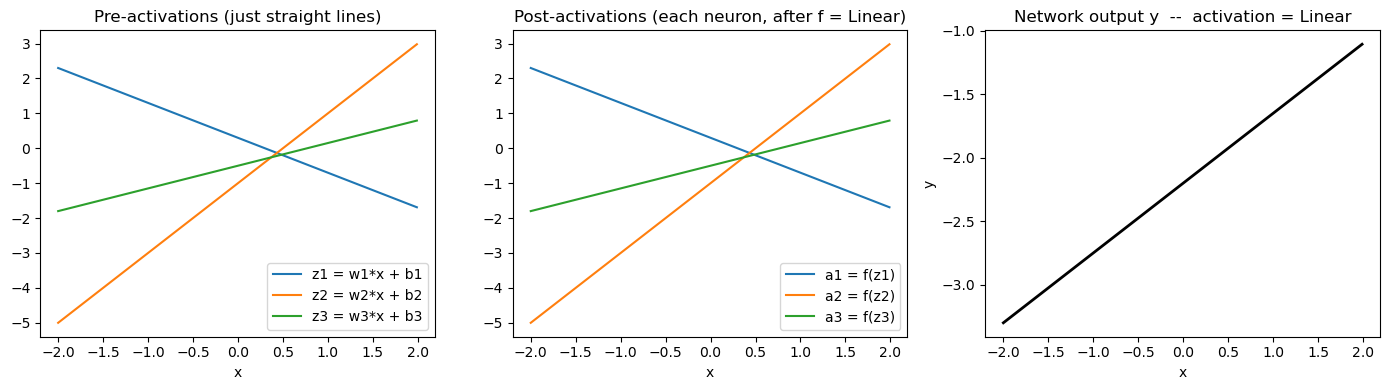

In [3]:
def linear(z):
    return z

y, zs, acts = shallow_network(x, linear, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)
plot_network(x, y, zs, acts, 'Linear')


**What just happened:** the output is a straight line -- no matter how many hidden units
we add, or how many layers we stack, a linear activation function can *only ever* produce a
straight line. Mathematically, a linear function of a linear function is still linear, so
stacking linear layers collapses into a single linear layer.

**Takeaway:** without a nonlinear activation function somewhere in the network, "deep"
learning is pointless -- you'd get nothing more powerful than linear regression, no matter
how many layers you add. **This is the whole reason nonlinear activation functions exist.**


## 2. Sigmoid

**Formula:** $f(z) = \sigma(z) = \dfrac{1}{1 + e^{-z}}$

**Range:** $(0, 1)$

**Shape:** smooth "S" curve.

**Where it's used:** historically the default choice for hidden layers; today mostly
used at the **output layer for binary classification**, since its output can be read
as a probability.


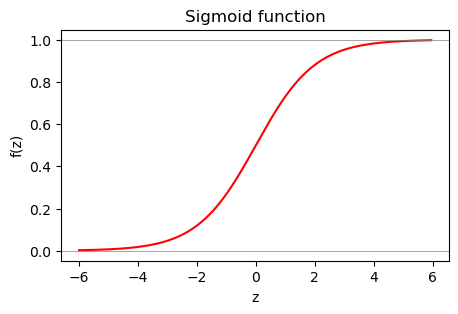

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Plot the function itself first
z_range = np.arange(-6, 6, 0.05)
plt.figure(figsize=(5, 3))
plt.plot(z_range, sigmoid(z_range), 'r-')
plt.title('Sigmoid function'); plt.xlabel('z'); plt.ylabel('f(z)')
plt.axhline(0, color='gray', lw=0.5); plt.axhline(1, color='gray', lw=0.5)
plt.show()


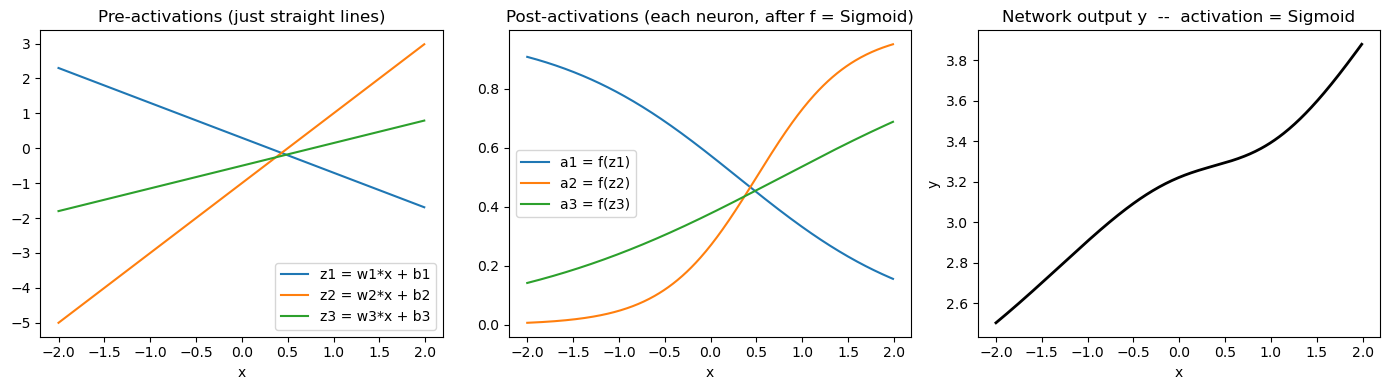

In [5]:
y, zs, acts = shallow_network(x, sigmoid, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)
plot_network(x, y, zs, acts, 'Sigmoid')


**What changed:** instead of sharp straight lines, we now get smooth, curved bends.
This is nonlinear -- exactly what we needed.

**Problem -- saturation / vanishing gradients:** for very large or very negative `z`,
the curve is almost flat. A flat curve means a near-zero slope (gradient). During
training, the network learns by following gradients -- if the gradient is close to
zero, that part of the network barely updates. In deep networks this effect compounds
across layers and learning can grind to a halt. This is called the
**vanishing gradient problem**. We'll return to this once we study backpropagation.


## 3. Tanh (Hyperbolic Tangent)

**Formula:** $f(z) = \tanh(z) = \dfrac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$

**Range:** $(-1, 1)$

**Shape:** same S-curve family as sigmoid, but centered at 0 instead of 0.5.


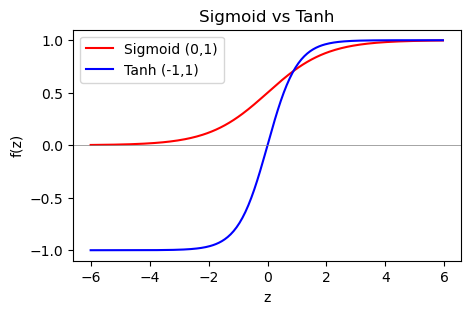

In [6]:
def tanh(z):
    return np.tanh(z)

plt.figure(figsize=(5, 3))
plt.plot(z_range, sigmoid(z_range), 'r-', label='Sigmoid (0,1)')
plt.plot(z_range, tanh(z_range), 'b-', label='Tanh (-1,1)')
plt.title('Sigmoid vs Tanh'); plt.xlabel('z'); plt.ylabel('f(z)')
plt.axhline(0, color='gray', lw=0.5)
plt.legend()
plt.show()


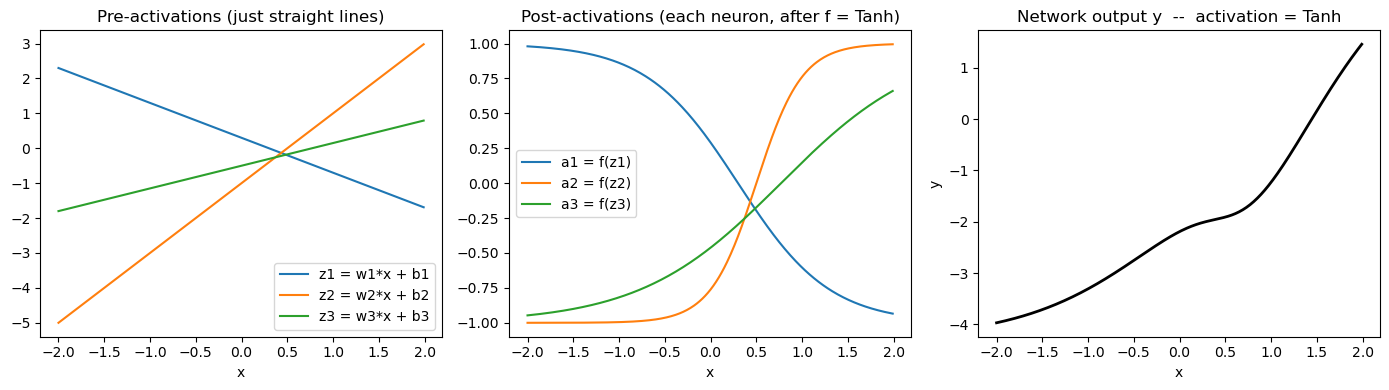

In [7]:
y, zs, acts = shallow_network(x, tanh, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)
plot_network(x, y, zs, acts, 'Tanh')


**Why prefer tanh over sigmoid?** Being zero-centered means the outputs of a layer
are balanced around zero rather than always positive, which generally makes gradients
flow more evenly through the network during training -- often leading to slightly
faster, more stable learning than sigmoid.

**Same weakness as sigmoid:** it still saturates (flattens) at large positive/negative
`z`, so it still suffers from vanishing gradients, just usually somewhat less severely.


## 4. ReLU (Rectified Linear Unit)

**Formula:** $f(z) = \max(0, z)$

**Range:** $[0, \infty)$

**Shape:** flat at 0 for negative inputs, then a straight 45&deg; line for positive
inputs -- a sharp "elbow" bend rather than a smooth curve.


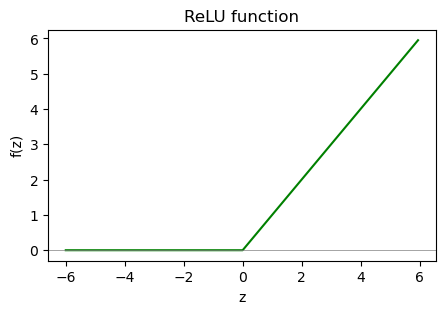

In [8]:
def relu(z):
    return np.maximum(0, z)

plt.figure(figsize=(5, 3))
plt.plot(z_range, relu(z_range), 'g-')
plt.title('ReLU function'); plt.xlabel('z'); plt.ylabel('f(z)')
plt.axhline(0, color='gray', lw=0.5)
plt.show()


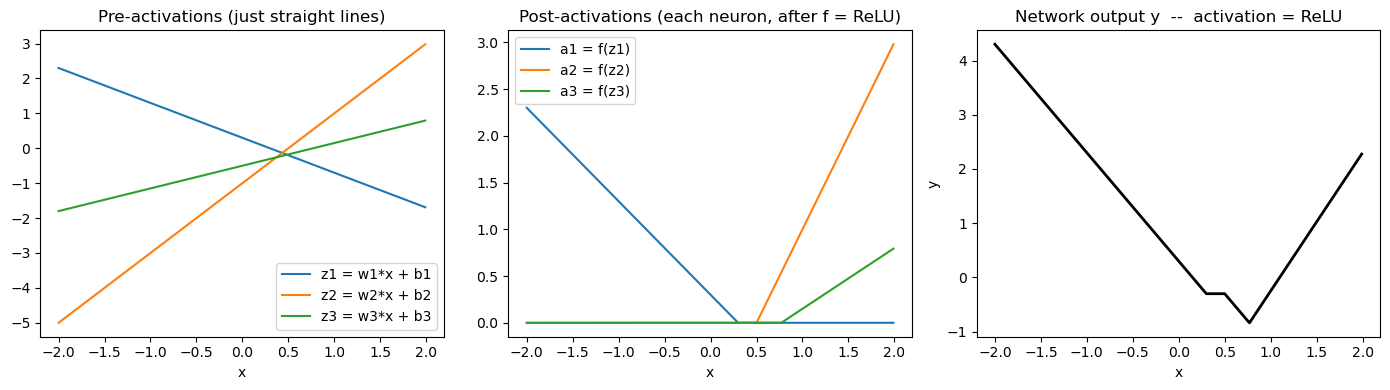

In [9]:
y, zs, acts = shallow_network(x, relu, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)
plot_network(x, y, zs, acts, 'ReLU')


**What changed:** the output is now made of sharp, piecewise-straight bends instead
of smooth curves -- like folding a piece of paper instead of bending rubber.

**Why it's the modern default:**
- Extremely cheap to compute -- just a comparison, no exponentials.
- No saturation for `z > 0` -- the gradient is exactly 1 there, so learning doesn't
  slow down the way it does with sigmoid/tanh.

**Problem -- "dying ReLU":** if a neuron's weights end up such that `z` is always
negative for every training example, that neuron always outputs 0, and its gradient
is always 0 too. It stops learning permanently -- it has "died" and can never come
back to life during training.


## 5. Leaky ReLU

**Formula:**
$$f(z) = \begin{cases} z & z \geq 0 \\ 0.01z & z < 0 \end{cases}$$

**Range:** $(-\infty, \infty)$

**Why it exists:** a direct fix for the dying ReLU problem. Instead of flattening
negative inputs to exactly 0, it lets a small fraction (commonly 1%) of the negative
value through, keeping the gradient non-zero even when `z < 0`.


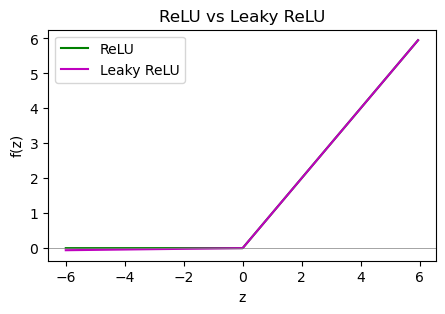

In [10]:
def leaky_relu(z, alpha=0.01):
    return np.where(z >= 0, z, alpha * z)

plt.figure(figsize=(5, 3))
plt.plot(z_range, relu(z_range), 'g-', label='ReLU')
plt.plot(z_range, leaky_relu(z_range), 'm-', label='Leaky ReLU')
plt.title('ReLU vs Leaky ReLU'); plt.xlabel('z'); plt.ylabel('f(z)')
plt.axhline(0, color='gray', lw=0.5)
plt.legend()
plt.show()


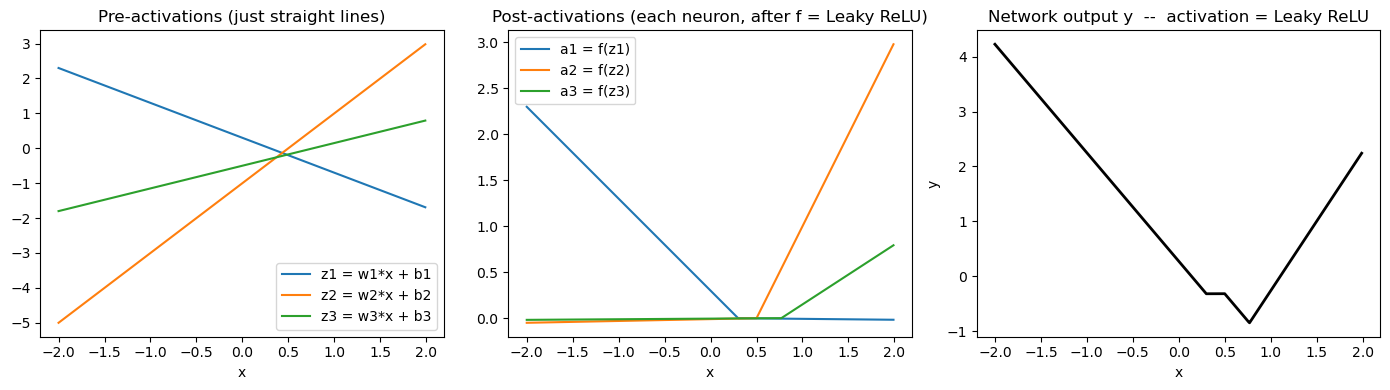

In [11]:
y, zs, acts = shallow_network(x, leaky_relu, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)
plot_network(x, y, zs, acts, 'Leaky ReLU')


**What changed:** visually almost identical to ReLU in this small example, but notice
in the "ReLU vs Leaky ReLU" plot that the pink line has a slight slope for negative `z`
instead of being perfectly flat. That small slope is enough to keep gradients alive and
prevent neurons from dying.

**Trade-off:** slightly more computation than plain ReLU, and the extra slope (`0.01`)
is a manually chosen number (a hyperparameter) rather than something the network learns
on its own -- though variants like Parametric ReLU (PReLU) do let the network learn
that slope.


## 6. Softmax -- a different kind of activation

All five functions above take **one number in, one number out**. Softmax is different:
it takes a **vector of scores** (one per class) and turns them into **probabilities that
sum to 1**.

**Formula:** for a vector of scores $z = (z_1, z_2, ..., z_k)$:
$$\text{softmax}(z)_i = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$$

**Where it's used:** only at the **output layer**, for multi-class classification
problems (e.g. "is this image a cat, dog, or bird?") -- never in hidden layers.

**Why exponentials?** Exponentiating first (before normalizing) makes larger scores
dominate more strongly, and guarantees every output is positive -- both properties are
needed for the result to be interpreted as a probability distribution.


Cat    raw score z =  2.00   ->   probability = 0.659
Dog    raw score z =  1.00   ->   probability = 0.242
Bird   raw score z =  0.10   ->   probability = 0.099


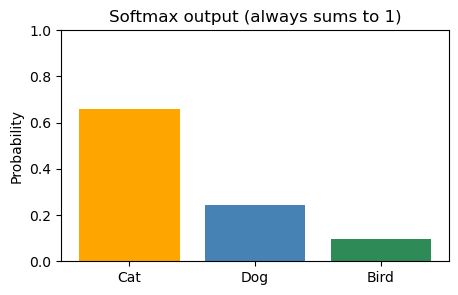


Sum of probabilities: 1.0


In [12]:
def softmax(z):
    e = np.exp(z - np.max(z))  # subtract max first -- keeps the numbers small and stable
    return e / np.sum(e)

# Example: raw output scores from the network for 3 classes
classes = ['Cat', 'Dog', 'Bird']
scores = np.array([2.0, 1.0, 0.1])   # these are the z's -- can be any real numbers

probs = softmax(scores)

for c, s, p in zip(classes, scores, probs):
    print(f'{c:5s}  raw score z = {s:5.2f}   ->   probability = {p:.3f}')

plt.figure(figsize=(5, 3))
plt.bar(classes, probs, color=['orange', 'steelblue', 'seagreen'])
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Softmax output (always sums to 1)')
plt.show()

print('\nSum of probabilities:', probs.sum())


**What to notice:**
- The highest raw score (`Cat = 2.0`) gets the highest probability, but every class still
  gets *some* probability (never exactly 0).
- The probabilities always add up to exactly **1.0** -- that's what makes softmax useful
  for classification: we can interpret the output as "how confident is the model in each
  class?"
- **Numerical stability tip:** in code, we subtract `max(z)` from every score before
  exponentiating. This doesn't change the final probabilities (the math cancels out)
  but prevents `e^z` from overflowing to huge numbers on a computer.
- Try changing the `scores` array above and re-running -- e.g. make all three scores
  equal, or make one score much larger than the others -- and see how the bar chart
  changes.


## 7. Putting it all together

One last plot comparing every function we covered, side by side.


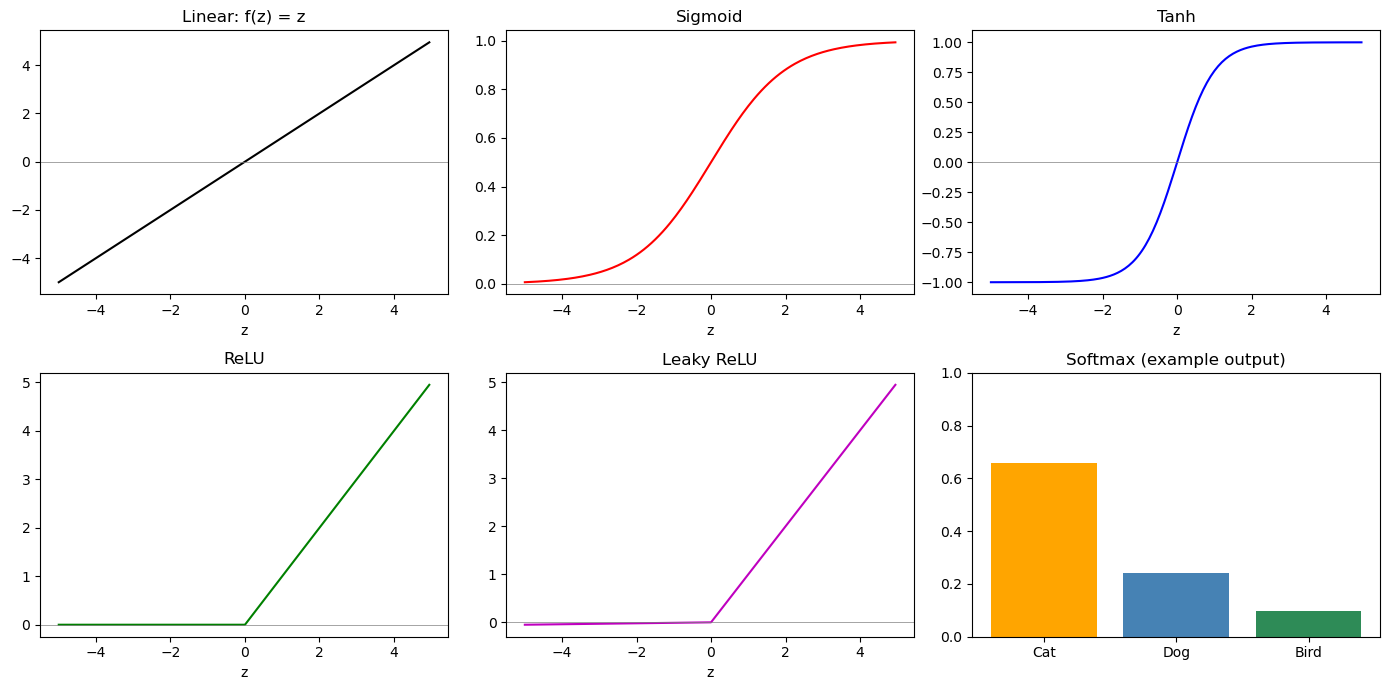

In [13]:
z_range = np.arange(-5, 5, 0.05)

fig, axs = plt.subplots(2, 3, figsize=(14, 7))

axs[0,0].plot(z_range, linear(z_range), 'k'); axs[0,0].set_title('Linear: f(z) = z')
axs[0,1].plot(z_range, sigmoid(z_range), 'r'); axs[0,1].set_title('Sigmoid')
axs[0,2].plot(z_range, tanh(z_range), 'b'); axs[0,2].set_title('Tanh')
axs[1,0].plot(z_range, relu(z_range), 'g'); axs[1,0].set_title('ReLU')
axs[1,1].plot(z_range, leaky_relu(z_range), 'm'); axs[1,1].set_title('Leaky ReLU')

axs[1,2].bar(classes, probs, color=['orange', 'steelblue', 'seagreen'])
axs[1,2].set_title('Softmax (example output)')
axs[1,2].set_ylim(0, 1)

for a in axs.flat[:5]:
    a.axhline(0, color='gray', lw=0.5)
    a.set_xlabel('z')

plt.tight_layout()
plt.show()


## 8. Summary Table

| Function | Range | Used in | Main strength | Main weakness |
|---|---|---|---|---|
| Linear | (-inf, inf) | (illustrative only) | Simple | Whole network collapses to linear |
| Sigmoid | (0, 1) | Binary classification output | Smooth, interpretable as probability | Vanishing gradients |
| Tanh | (-1, 1) | Hidden layers (older networks) | Zero-centered | Vanishing gradients |
| ReLU | [0, inf) | Hidden layers (default today) | Fast, no saturation for z>0 | Dying ReLU |
| Leaky ReLU | (-inf, inf) | Hidden layers | Fixes dying ReLU | Extra hyperparameter |
| Softmax | (0,1), sums to 1 | Output layer, multi-class | Gives class probabilities | Only makes sense at output layer |

## Questions

1. Why can't we just use a linear activation function in a deep network?
2. What problem do sigmoid and tanh share, and why does it happen?
3. What is the "dying ReLU" problem, and how does Leaky ReLU fix it?
4. Why is softmax applied to a vector instead of a single number, and why only at the
   output layer?
5. If you were building a hidden layer today, which activation function would you
   reach for first, and why?


## 9. Your Turn: Spot the Dead Neuron (~5 min)

Look back at the **ReLU** section above, specifically the new *middle* panel
(post-activations `a1, a2, a3`). Notice each curve is flat at `0` for *part* of
the range and then rises -- that's ReLU switching a neuron "off" (`z < 0`) or
"on" (`z > 0`) as `x` changes. In the plotted range (`x` from -2 to 2), every
neuron turns on somewhere, so none of them is dead across the *whole* range yet.

**Task:**
1. Run `shallow_network` with `relu` and capture `acts = (a1, a2, a3)`.
2. For each of the 3 neurons, check whether **every single value** in its
   activation array is exactly `0` (hint: `np.all(a == 0)`) over
   `x = np.arange(-2, 2, 0.01)`. Confirm none are fully dead here.
3. Now shift the input range to only positive, larger `x`:
   `x2 = np.arange(2, 6, 0.01)`. Recompute `z1,z2,z3` and `a1,a2,a3` for `x2`
   (same `w1,b1,w2,b2,w3,b3`) and re-run the "all zero" check.
4. One neuron should now be permanently `0` on this new range. Which one?
   Look at its weight `w` -- is it positive or negative? What happens to
   `z = w*x + b` as `x` keeps growing if `w` is negative?

This is the real danger of "dying ReLU": a neuron can look perfectly fine on
the input range you happened to test, and still be permanently off once real
inputs shift outside that range.


In [14]:
# TODO: complete this cell
# Part A: confirm no neuron is fully dead on the original range
y, zs, acts = shallow_network(x, relu, w1, b1, w2, b2, w3, b3, v1, v2, v3, b_out)

# your code here: loop over acts, print np.all(a == 0) for each neuron


# Part B: shift the input range and check again
x2 = np.arange(2, 6, 0.01)

# your code here:
# 1. compute z1,z2,z3 for x2 (reuse w1,b1,w2,b2,w3,b3)

# 2. apply relu to get a1,a2,a3

# 3. print np.all(a == 0) for each neuron -- which one is now permanently dead?
